# Ri Outlier Diagnostic

Identify whether extreme validation Ri values are produced by the sounding side, ERA5 side, or both.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from src.stability.validation import agreement_statistics
from src.viz import plotting_config

pairs = xr.open_zarr(project_root / "data/interim/sounding_era5_pairs.zarr", consolidated=False)
soundings = xr.open_zarr(project_root / "data/interim/soundings_spb.zarr", consolidated=False)
era5 = xr.open_zarr(project_root / "data/interim/era5_spb.zarr", consolidated=False)
valid = np.isfinite(pairs.ri_sounding) & np.isfinite(pairs.ri_era5)
paired = pairs.where(valid, drop=True)
ri_abs = {"Sounding": np.abs(paired.ri_sounding.values), "ERA5": np.abs(paired.ri_era5.values)}
print(f"Validation N={paired.sizes['time']}")
print("Sounding variables:", list(soundings.data_vars))
print("ERA5 variables:", list(era5.data_vars), "pressure levels:", era5.pressure_level.values)

Validation N=5188
Sounding variables: ['height_agl_m', 'temperature_k', 'valid', 'wind_direction_deg', 'relative_humidity_pct', 'ri_sounding', 'pressure_hpa', 'wind_speed_ms', 'station_id']
ERA5 variables: ['sp', 'u', 'd2m', 't', 'tp', 'tcc', 'v', 't2m', 'v10', 'blh', 'u10'] pressure levels: [1000.]


          median    p95     p99     p99.9
Sounding   0.639 27.601 252.534 14757.424
ERA5       1.160 20.602  79.904  1226.976


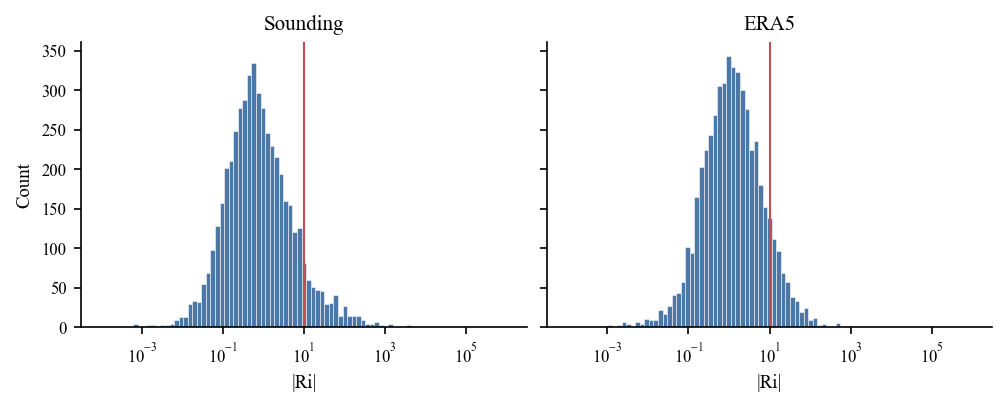

In [2]:
percentiles = pd.DataFrame(
    {name: np.nanpercentile(values, [50, 95, 99, 99.9]) for name, values in ri_abs.items()},
    index=["median", "p95", "p99", "p99.9"],
).T
print(percentiles.to_string(float_format=lambda x: f"{x:.3f}"))

with plt.rc_context(plotting_config()):
    fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.6), sharey=True, constrained_layout=True)
    bins = np.logspace(-4, 6, 90)
    for ax, (name, values) in zip(axes, ri_abs.items()):
        values = values[np.isfinite(values) & (values > 0)]
        ax.hist(values, bins=bins, color="#4c78a8", edgecolor="white", linewidth=0.25)
        ax.axvline(10, color="#c44e52", linewidth=1.0)
        ax.set_xscale("log")
        ax.set_title(name)
        ax.set_xlabel("|Ri|")
    axes[0].set_ylabel("Count")
    plt.show()

In [3]:
sounding_outlier = ri_abs["Sounding"] > 10
era5_outlier = ri_abs["ERA5"] > 10
cross = pd.DataFrame(
    [[int((sounding_outlier & era5_outlier).sum()), int((sounding_outlier & ~era5_outlier).sum())],
     [int((~sounding_outlier & era5_outlier).sum()), int((~sounding_outlier & ~era5_outlier).sum())]],
    index=["Sounding outlier", "Sounding sane"],
    columns=["ERA5 outlier", "ERA5 sane"],
)
print(cross)
print("\nPercent of validation sample:")
print((100 * cross / paired.sizes["time"]).to_string(float_format=lambda x: f"{x:.2f}%"))

                  ERA5 outlier  ERA5 sane
Sounding outlier           143        342
Sounding sane              421       4282

Percent of validation sample:
                  ERA5 outlier  ERA5 sane
Sounding outlier         2.76%      6.59%
Sounding sane            8.11%     82.54%


In [4]:
sounding_profile = soundings.sel(time=paired.time.values[sounding_outlier])
height = sounding_profile.height_agl_m.values
wind_speed = sounding_profile.wind_speed_ms.values
usable = np.isfinite(height) & np.isfinite(wind_speed)
lowest_height, lowest_wind = [], []
for i in range(height.shape[0]):
    idx = np.where(usable[i])[0]
    if len(idx) == 0:
        lowest_height.append(np.nan); lowest_wind.append(np.nan)
    else:
        j = idx[np.nanargmin(height[i, idx])]
        lowest_height.append(height[i, j]); lowest_wind.append(wind_speed[i, j])
lowest_height = np.asarray(lowest_height)
lowest_wind = np.asarray(lowest_wind)
sounding_lowest = pd.DataFrame({
    "lowest_height_m": np.nanpercentile(lowest_height, [0, 50, 95, 99, 100]),
    "lowest_wind_ms": np.nanpercentile(lowest_wind, [0, 50, 95, 99, 100]),
}, index=["min", "median", "p95", "p99", "max"])
print(sounding_lowest.to_string(float_format=lambda x: f"{x:.3f}"))
print(f"Extrapolates to 2 m: {(lowest_height > 2).sum()}/{len(lowest_height)}; lowest level >20 m: {(lowest_height > 20).sum()}/{len(lowest_height)}")

        lowest_height_m  lowest_wind_ms
min               0.000           0.000
median            0.000           3.087
p95               0.000           8.231
p99               0.000           9.774
max               2.000          13.890
Extrapolates to 2 m: 0/485; lowest level >20 m: 0/485


In [5]:
lat, lon = paired.attrs["era5_latitude"], paired.attrs["era5_longitude"]
era5_cell = era5.sel(latitude=lat, longitude=lon, method="nearest").sel(time=paired.time)
u10, v10 = era5_cell.u10.values, era5_cell.v10.values
u1000 = era5_cell.u.sel(pressure_level=1000).values
v1000 = era5_cell.v.sel(pressure_level=1000).values
ws10 = np.sqrt(u10**2 + v10**2)
ws1000 = np.sqrt(u1000**2 + v1000**2)
delta_u = np.sqrt((u1000 - u10)**2 + (v1000 - v10)**2)
rows = []
for label, mask in {"ERA5 outlier": era5_outlier, "ERA5 sane": ~era5_outlier}.items():
    rows.append({
        "subset": label, "N": int(mask.sum()), "dU_min": np.nanmin(delta_u[mask]),
        "dU_p05": np.nanpercentile(delta_u[mask], 5), "dU_median": np.nanmedian(delta_u[mask]),
        "dU_p95": np.nanpercentile(delta_u[mask], 95), "dU_max": np.nanmax(delta_u[mask]),
        "frac_dU_lt_0.5": float(np.mean(delta_u[mask] < 0.5)),
        "ws10_median": np.nanmedian(ws10[mask]), "ws1000_median": np.nanmedian(ws1000[mask]),
    })
du_stats = pd.DataFrame(rows)
print(du_stats.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

      subset    N  dU_min  dU_p05  dU_median  dU_p95  dU_max  frac_dU_lt_0.5  ws10_median  ws1000_median
ERA5 outlier  564   0.039   0.211      0.664   1.175   1.979           0.289        1.675          2.206
   ERA5 sane 4624   0.212   0.923      2.313   5.502  11.270           0.002        3.437          5.889


In [6]:
bounded = paired.where((np.abs(paired.ri_sounding) <= 10) & (np.abs(paired.ri_era5) <= 10), drop=True)
full_stats = agreement_statistics(paired)
bounded_stats = agreement_statistics(bounded)
def row(name, stats):
    miss_den = stats["false_negative"] + stats["true_positive"]
    return {"subset": name, "N": stats["n"], "Pearson r": stats["pearson_r"], "Spearman r": stats["spearman_r"],
            "RMSE": stats["rmse"], "bias": stats["bias"], "hit rate": stats["hit_rate"],
            "false alarm rate": stats["false_alarm_rate"], "miss rate": stats["false_negative"] / miss_den if miss_den else np.nan}
stats_df = pd.DataFrame([row("full", full_stats), row("both_|Ri|<=10", bounded_stats)])
print(stats_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

       subset    N  Pearson r  Spearman r     RMSE   bias  hit rate  false alarm rate  miss rate
         full 5188      0.005       0.680 2394.361 59.033     0.777             0.124      0.223
both_|Ri|<=10 4282      0.427       0.652    2.464 -0.037     0.777             0.144      0.223


In [7]:
note_path = project_root / "docs/notes/outlier_diagnostic_status.md"
note_path.parent.mkdir(parents=True, exist_ok=True)
A, B, C, D = cross.iloc[0, 0], cross.iloc[0, 1], cross.iloc[1, 0], cross.iloc[1, 1]
fmt = lambda x: f"{100 * x:.1f}%"
note = (
    "# Outlier Diagnostic Status\n\n"
    f"Using |Ri| > 10 as the outlier threshold, the validation sample has {A} two-sided outliers, {B} sounding-only outliers, {C} ERA5-only outliers, and {D} samples where both sides are within bounds. "
    f"That is a mixed one-sided pattern rather than one dataset alone failing: sounding-only is {fmt(B / paired.sizes['time'])}, ERA5-only is {fmt(C / paired.sizes['time'])}, and two-sided is {fmt(A / paired.sizes['time'])}. "
    f"Sounding-side outliers are not caused by interpolation/extrapolation from a too-high lowest reported level: among {len(lowest_height)} sounding outliers, the median lowest usable height is {np.nanmedian(lowest_height):.1f} m, the maximum is {np.nanmax(lowest_height):.1f} m, and {int((lowest_height > 2).sum())} require extrapolation to 2 m. "
    f"ERA5-side outliers are strongly associated with tiny 10 m to 1000 hPa shear: median delta-U is {du_stats.loc[0, 'dU_median']:.2f} m/s for ERA5 outliers versus {du_stats.loc[1, 'dU_median']:.2f} m/s for ERA5-sane samples, and {fmt(du_stats.loc[0, 'frac_dU_lt_0.5'])} of ERA5 outliers have delta-U < 0.5 m/s versus {fmt(du_stats.loc[1, 'frac_dU_lt_0.5'])} of ERA5-sane samples. "
    f"Restricting the continuous comparison to samples where both |Ri_sounding| <= 10 and |Ri_era5| <= 10 leaves N={bounded_stats['n']} and changes Pearson r from {full_stats['pearson_r']:.3f} to {bounded_stats['pearson_r']:.3f}, RMSE from {full_stats['rmse']:.1f} to {bounded_stats['rmse']:.2f}, and bias from {full_stats['bias']:.1f} to {bounded_stats['bias']:.2f}. "
    f"The bounded-sample categorical metrics remain close to the full sample: hit rate {fmt(bounded_stats['hit_rate'])} versus {fmt(full_stats['hit_rate'])}, false alarm rate {fmt(bounded_stats['false_alarm_rate'])} versus {fmt(full_stats['false_alarm_rate'])}. "
    "Recommendation for the paper validation section: report categorical and rank-based metrics as primary, report bounded |Ri| <= 10 continuous metrics as secondary, and explicitly document bulk-Ri numerical instability under near-calm or near-zero-shear conditions as a property of the formula.\n"
)
note_path.write_text(note)
print(f"Saved {note_path.relative_to(project_root)}")

Saved docs/notes/outlier_diagnostic_status.md
